
0: 448x640 2 persons, 1 bottle, 1 cup, 10 chairs, 7 potted plants, 1 dining table, 1 laptop, 1 refrigerator, 1 vase, 896.5ms
Speed: 5.0ms preprocess, 896.5ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 2 persons, 1 bottle, 1 cup, 10 chairs, 7 potted plants, 1 dining table, 1 laptop, 1 refrigerator, 1 vase, 851.2ms
Speed: 3.1ms preprocess, 851.2ms inference, 1.8ms postprocess per image at shape (1, 3, 448, 640)
Tempo de inferência: 0.8669 segundos


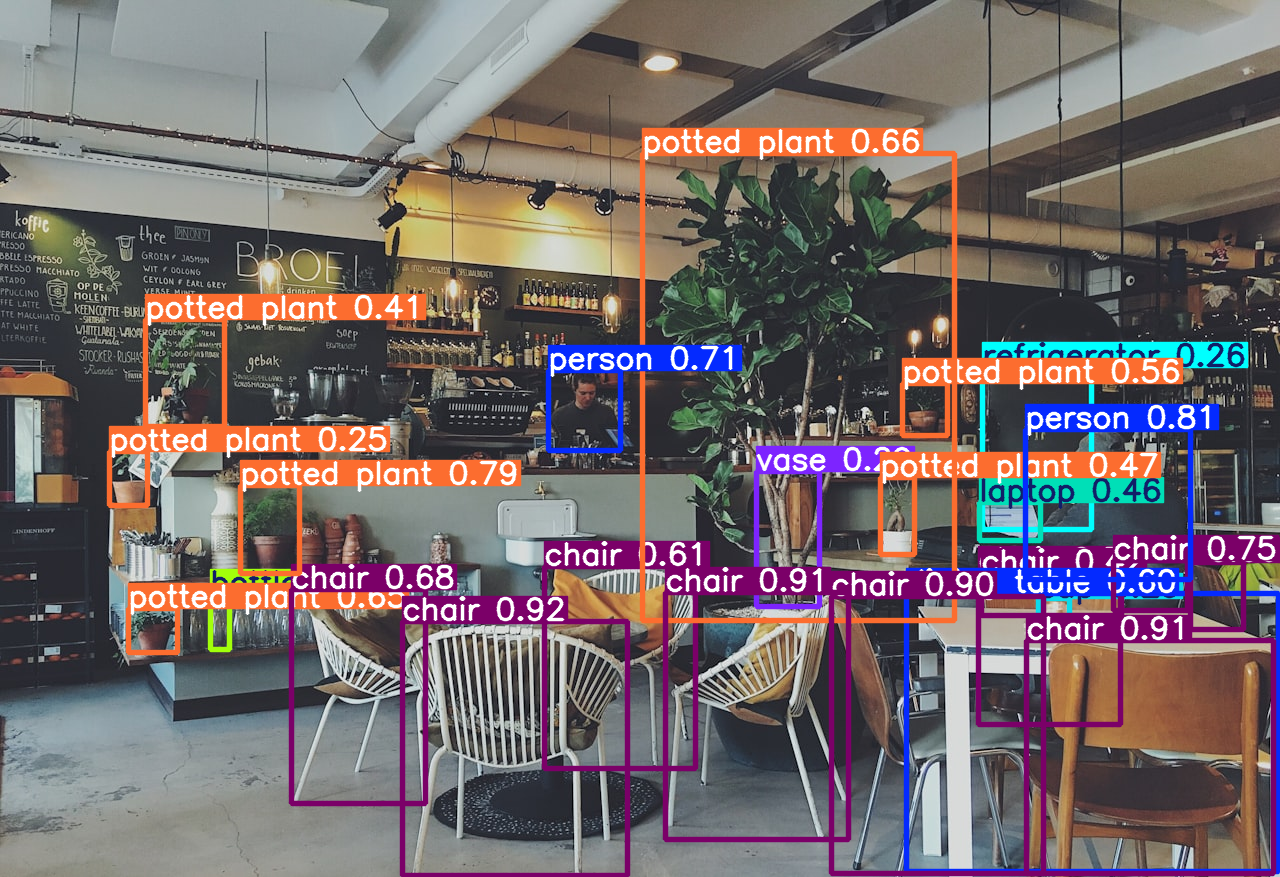

In [9]:
!pip install ultralytics -q
import requests
import cv2
import numpy as np
import time
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

url="https://images.unsplash.com/photo-1554118811-1e0d58224f24?q=80&w=1280"
response = requests.get(url)

image_array = np.asarray(bytearray(response.content), dtype=np.uint8)
img = cv2.imdecode(image_array, cv2.IMREAD_COLOR)

# 2. Modelo
# Para testar as outras versões, mude aqui para "yolov8n.pt" ou "yolov8s.pt"
model = YOLO("yolov8m.pt")

# 3. Tempo de inferência
results = model(img)

start = time.perf_counter()
results = model(img)
end = time.perf_counter()

tempo = end - start
print(f"Tempo de inferência: {tempo:.4f} segundos")

# 4. Anotar imagem
annotated = results[0].plot()

# 5. Mostrar imagem (Colab)
cv2_imshow(annotated)